# One-time held-out check of closure and the D3 link: evaluation assembly (`eval.py`)

This notebook is the **S8 ASSEMBLE** step of an iteration-4, CPU-only, $0 evaluation. The step before it opened two sealed research folds exactly once:

- **R1**: the sealed RQ1 held-out fold. It tests whether ego-network *closure* around a new research concept precedes its emergence. Four Holm-corrected tests are used: raw `closure`, turnover-residualised `closure_resT`, persistent-neighbour `closure_persist`, and `constraint`.
- **D1**: held-out openness → W2 outcome regressions. They are *descriptive only*.
- **D3**: a concept-level partial Spearman link between early closure (ages 3–5) and later host-entry anchoring. It uses 2,000 bootstrap draws and 10,000 Freedman–Lane permutations.

`eval.py` **re-opens nothing**. It reads the recorded outputs (verdicts, frozen specs, integrity and power reports, screen-fold references, and pytest logs) and does four things:
1. It checks that the frozen specs `eval_spec.json` and `d3_spec.json` still match the sha256 hashes logged at freeze time.
2. It assembles the R1 event-study, pooled-panel and Holm tables. It then applies the **frozen kill mapping** (`R1_DEAD` / `R1_ALIVE…`) and the frozen **reading test**, and adds a descriptive inverse-variance screen+held-out synthesis.
3. It assembles the descriptive D1 table and the D3 decision.
4. It writes `results/tables/*.csv`, `results/r1/r1_summary.json`, the forest plot `figures/F1_r1_forest.png`, `results_note.md` and `eval_out.json` (schema `exp_eval_sol_out`).

**Demo data.** `mini_demo_data.json` bundles every file that `eval.py` reads (~210 KB), keyed by its original relative path. The notebook writes the bundle into a local workspace folder and then runs the original functions **unchanged**. The code is copied verbatim from `eval.py`; only the workspace path `WS` differs.

Headline results from the original run: R1 is `R1_DEAD`, because raw closure has Holm p = 0.147, while `closure_persist` is CONFIRMED (Holm p = 0.015). The verdict is MIXED and the reading test is NOT_SUPPORTED. D3 is NULL.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


## Imports
The original import block of `eval.py`, verbatim. Notebook-only imports for the final display cell come after it.

In [2]:
from __future__ import annotations

import hashlib
import json
import math
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import norm

# --- notebook-only imports (visualisation / display)
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


## Data loading
The demo data is loaded from GitHub, with a local fallback to `mini_demo_data.json` next to the notebook.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_aMfESsKemlKH/round-4/evaluation-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()
print(data["description"])
print(f"\n{len(data['files'])} bundled input files:")
for k, v in data["files"].items():
    print(f"  {len(v):>7} chars  {k}")


Input bundle for eval.py (S8 assemble step of the one-look held-out evaluation). 'files' maps each workspace-relative path eval.py reads to its exact text; 'reference_metrics_agg' is the metrics_agg block of the original eval_out.json, for comparison.

18 bundled input files:
    43967 chars  results/integrity_report.json
     5381 chars  results/pre_open_power.json
      444 chars  logs/eval_freeze_log.jsonl
     4447 chars  eval_spec.json
     6193 chars  d3_spec.json
    27058 chars  results/d3/d3_results.json
    10266 chars  results/r1/verdict_heldout.json
     4826 chars  results/r1/r1_capture_balance.json
     2902 chars  results/d1/confirmation.json
    26107 chars  deps_run/exp5/heldout_spec.json
    44321 chars  deps_run/exp5/results/event_study/primary_family.json
     2560 chars  deps_run/exp5/results/confirm_selftest.json
     7099 chars  deps_run/exp6/results/heldout/heldout_spec.json
     3883 chars  deps_run/exp6/results/d1/coef_table_primary.csv
      370 chars  logs/s

## Config

`eval.py` is a deterministic assembly step with **no tunable computational parameters**: no iterations, sampling or training. The heavy computation happened in earlier steps: the D3 bootstrap (2,000 draws) and permutations (10,000) in `d3_link.py`, and the R1 bootstrap in exp_5's `confirm_heldout.py`. Its results come in through the bundled JSON files, so this notebook runs at the **original, full scale** in a few seconds.

The only settings are where the local workspace is rebuilt and whether to rebuild it from the bundle.

In [5]:
# Local folder that stands in for the original evaluation workspace (WS in eval.py)
WORKSPACE_DIR = "eval_ws"
# Re-create the input files from `data` before running (set False to reuse an existing folder)
MATERIALIZE_INPUTS = True


## Rebuild the evaluation workspace from `data`

Each bundled file is written back, as its **exact original text**, to its original relative path under `WORKSPACE_DIR`. The paths include `results/…`, `deps_run/exp5/…`, `deps_run/exp6/…` and `logs/…`. The original path logic in `eval.py` therefore works without edits. The byte-exact copy matters because `check_frozen()` re-hashes the two frozen specs.

In [6]:
if MATERIALIZE_INPUTS:
    for rel, entry in data["files"].items():
        p = Path(WORKSPACE_DIR) / rel
        p.parent.mkdir(parents=True, exist_ok=True)
        p.write_text(entry)  # exact original text
print(f"workspace rebuilt in ./{WORKSPACE_DIR}: {sum(1 for _ in Path(WORKSPACE_DIR).rglob("*") if _.is_file())} files")


workspace rebuilt in ./eval_ws: 18 files


## Setup: paths, logging and constants

This cell is the original module-level setup:
- the workspace paths `E5`/`E6` (screen-fold references from exp_5 and exp_6) and `RES`/`TAB`/`FIG` (outputs);
- the loguru sinks;
- the row families.

`HOLM_ROWS` is the pre-registered 4-test Holm family. `CONF_ROWS` holds all confirmatory and descriptive event-study rows. `CODES` maps categorical labels to numeric metric codes for `eval_out.json`.

In [7]:
WS = Path(WORKSPACE_DIR).resolve()  # notebook: was Path(__file__).resolve().parent (the eval workspace)
E5, E6 = WS / "deps_run" / "exp5", WS / "deps_run" / "exp6"
RES, TAB, FIG = WS / "results", WS / "results" / "tables", WS / "figures"

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(WS / "logs").mkdir(exist_ok=True)
logger.add(WS / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

CONF_ROWS = ["closure", "closure_resT", "closure_persist", "constraint", "cdeg_diag", "xc_excess", "effsize", "wmz",
             "closure_resT_cc", "closure_resT_raw", "d_wmz", "d_closure"]
HOLM_ROWS = ["closure_resT", "closure_persist", "constraint", "closure"]
FOREST_ROWS = ["closure", "closure_resT", "closure_persist", "constraint", "xc_excess", "wmz", "cdeg_diag", "effsize"]
CODES = dict(
    r1_status={"R1_DEAD": 0, "R1_ALIVE": 1, "R1_ALIVE+TURNOVER_PROOF": 2, "R1_ALIVE+PERSISTENT": 3, "R1_ALIVE+TURNOVER_PROOF+PERSISTENT": 4},
    r1_reading_label={"CONTRADICTED": -1, "NOT_SUPPORTED": 0, "SIGN_CONSISTENT": 1, "SUPPORTED": 2},
    r1_verdict={"MIXED": 0, "BROKERAGE": 1, "TURNOVER": 2},
    d3_decision={"REVERSED": -1, "NULL": 0, "SCREEN_ONLY": 1, "KEPT": 2},
)


## Helpers
`fnum` parses a value to a finite float, or returns `None` if it can't. `excl0` tests whether a CI excludes 0. `fmt` and `fci` are formatting helpers. `clean` replaces NaN/inf with `None` so the output is valid JSON. `pytest_passed` parses the pre-open test logs. `check_frozen` **refuses to run** if either frozen spec changed after the freeze time recorded in `logs/eval_freeze_log.jsonl`.

In [8]:
# ----------------------------------------------------------------------------- helpers
def jl(p: Path) -> dict:
    return json.loads(p.read_text())


def fnum(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if math.isfinite(v) else None


def excl0(ci) -> bool:
    lo, hi = fnum(ci[0]), fnum(ci[1])
    return lo is not None and hi is not None and (lo > 0 or hi < 0)


def fmt(x, d=3) -> str:
    v = fnum(x)
    return "NA" if v is None else f"{v:+.{d}f}"


def fci(ci, d=3) -> str:
    return f"[{fmt(ci[0], d)}, {fmt(ci[1], d)}]"


def clean(o):
    """Recursively replace NaN/inf by None so the JSON is standard."""
    if isinstance(o, dict):
        return {k: clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (float, np.floating)):
        return float(o) if math.isfinite(o) else None
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o


def pytest_passed(p: Path) -> int:
    mt = re.search(r"(\d+) passed", p.read_text())
    return int(mt.group(1)) if mt else 0


def check_frozen() -> dict:
    out = {}
    logged = {}
    for line in (WS / "logs" / "eval_freeze_log.jsonl").read_text().splitlines():
        r = json.loads(line)
        logged[r["file"]] = (r["sha256"], r["utc_iso"])
    for f in ("eval_spec.json", "d3_spec.json"):
        h = hashlib.sha256((WS / f).read_bytes()).hexdigest()
        if h != logged[f][0]:
            raise SystemExit(f"REFUSED: {f} changed after freeze")
        out[f] = dict(sha256=h, frozen_utc=logged[f][1])
    return out


## R1 assembly: screen vs held-out, Holm decisions, kill mapping and reading test

`r1_assemble` does the following:
- It joins the exp_5 **screen** results (`primary_family.json`, `confirm_selftest.json`) with the one-look **held-out** verdict (`verdict_heldout.json`), row by row. Rows are compared on the event-study `S` over k = −3..0 and on the pooled-panel `coef(futE)`.
- It copies the Holm tests verbatim from the verdict.
- It applies the **frozen kill mapping**. R1 is ALIVE only if raw `closure` is Holm-CONFIRMED; `+TURNOVER_PROOF` and `+PERSISTENT` are added for the other two rows.
- It applies the **frozen reading test** ("focused in the wide ego network, open at the top"). The precedence is CONTRADICTED > SUPPORTED > SIGN_CONSISTENT > NOT_SUPPORTED.
- It builds the sample accounting, including the pre-declared fallback to screen never-controls when fewer than 20 treated concepts are matched.
- It computes a *descriptive* two-fold inverse-variance synthesis with Cochran's Q and I².
- It writes the CSV tables and `r1_summary.json`.

In [9]:
# ----------------------------------------------------------------------------- R1
def r1_assemble(power: dict) -> dict:
    spec = jl(E5 / "heldout_spec.json")
    pf = jl(E5 / "results" / "event_study" / "primary_family.json")
    st = jl(E5 / "results" / "confirm_selftest.json")
    v = jl(RES / "r1" / "verdict_heldout.json")
    cap = jl(RES / "r1" / "r1_capture_balance.json")
    dirs = spec["directions"]
    # R1-1 event-study rows
    es_rows = []
    for r in CONF_ROWS:
        s, h = pf["rows"][r]["primary"], v["rows"][r]
        d = dirs.get(r)
        pkey = "p_one_neg" if d == "negative" else ("p_one_pos" if d == "positive" else None)
        es_rows.append(dict(row=r, spec_direction=d or "none (descriptive)", estimator_frozen=spec["estimator_per_row"].get(r, "event_study"),
                            S_screen=s["S"], ci_screen_lo=s["ci"][0], ci_screen_hi=s["ci"][1],
                            p_one_screen=s.get(pkey) if pkey else None,
                            S_heldout=h["S"], ci_heldout_lo=h["ci"][0], ci_heldout_hi=h["ci"][1],
                            p_one_heldout=h.get(pkey) if pkey else None, p_two_heldout=h.get("p"),
                            same_sign=bool(np.sign(s["S"]) == np.sign(h["S"])) if fnum(h["S"]) is not None else None,
                            ci_heldout_excludes_0=excl0(h["ci"]),
                            mde_es=spec["mde_table"].get(r, {}).get("event_study")))
    # R1-2 pooled panel rows
    pp_rows = []
    for r in CONF_ROWS:
        h = v["panel"].get(r, {})
        sp = st["panel"].get(r) or pf["pooled_panel"].get(r) or {}
        d = dirs.get(r)
        pkey = "p_one_neg" if d == "negative" else ("p_one_pos" if d == "positive" else None)
        z = (fnum(h.get("coef")) / fnum(h.get("se"))) if fnum(h.get("se")) else None
        pp_rows.append(dict(row=r, spec_direction=d or "none (descriptive)", coef_screen=sp.get("coef"), se_screen=sp.get("se"),
                            coef_heldout=h.get("coef"), se_heldout=h.get("se"),
                            ci_heldout_lo=(h["coef"] - 1.96 * h["se"]) if fnum(h.get("se")) else None,
                            ci_heldout_hi=(h["coef"] + 1.96 * h["se"]) if fnum(h.get("se")) else None,
                            p_one_heldout=h.get(pkey) if pkey else None,
                            p_two_heldout=float(2 * norm.sf(abs(z))) if z is not None else None,
                            n_concept_years=h.get("n"), n_concepts=h.get("n_concepts"),
                            mde_panel=spec["mde_table"].get(r, {}).get("pooled_panel")))
    # R1-3 Holm tests (verbatim from the script)
    tests = v["tests"]
    # R1-4 verdict
    det = v["verdict_detail"]
    S_raw, S_res = v["rows"]["closure"]["S"], v["rows"]["closure_resT"]["S"]
    retention = abs(S_res) / abs(S_raw) if fnum(S_raw) else None
    # R1-7 kill mapping (frozen in eval_spec.json)
    alive = tests["closure"]["decision"] == "CONFIRMED"
    status = "R1_DEAD"
    if alive:
        status = "R1_ALIVE"
        if tests["closure_resT"]["decision"] == "CONFIRMED":
            status += "+TURNOVER_PROOF"
        if tests["closure_persist"]["decision"] == "CONFIRMED":
            status += "+PERSISTENT"
    reversed_ = bool(fnum(tests["closure"]["coef"]) is not None and tests["closure"]["coef"] > 0)
    # R1-8 reading test (frozen precedence: CONTRADICTED, SUPPORTED, SIGN_CONSISTENT, NOT_SUPPORTED)
    c, x = v["rows"]["constraint"], v["rows"]["xc_excess"]
    clo = tests["closure"]["coef"] < 0
    comp = dict(closure_coef_neg=bool(clo), closure_confirmed=bool(alive), S_constraint_pos=bool(c["S"] > 0),
                S_xc_excess_pos=bool(x["S"] > 0),
                constraint_ci_excludes_0_pos=bool(c["ci"][0] > 0), xc_excess_ci_excludes_0_pos=bool(x["ci"][0] > 0),
                constraint_ci_excludes_0_neg=bool(c["ci"][1] < 0), xc_excess_ci_excludes_0_neg=bool(x["ci"][1] < 0))
    if comp["constraint_ci_excludes_0_neg"] or comp["xc_excess_ci_excludes_0_neg"]:
        reading = "CONTRADICTED"
    elif clo and alive and comp["S_constraint_pos"] and comp["S_xc_excess_pos"] and (comp["constraint_ci_excludes_0_pos"] or comp["xc_excess_ci_excludes_0_pos"]):
        reading = "SUPPORTED"
    elif clo and comp["S_constraint_pos"] and comp["S_xc_excess_pos"] and not (comp["constraint_ci_excludes_0_pos"] or comp["xc_excess_ci_excludes_0_pos"]):
        reading = "SIGN_CONSISTENT"
    else:
        reading = "NOT_SUPPORTED"
    held = [k for k, val in comp.items() if val and not k.endswith("_neg")]
    reading_note = (f"components holding on held-out: {held}; the frozen rule needs closure CONFIRMED for SUPPORTED and "
                    "'neither CI excludes 0' for SIGN_CONSISTENT")
    # R1-5 sample accounting
    exp_n = spec["expected_heldout_n"]
    na = cap.get("closure_persist_na") or {}
    acct = dict(n_onsets=v["n_onsets"], n_matched=v["n_matched"], match_rate=v["n_matched"] / v["n_onsets"] if v["n_onsets"] else None,
                n_never_controls_pool=cap["run_fold_calls"][-1]["n_never"], n_matched_before_fallback=cap["run_fold_calls"][0]["n_matched"],
                n_never_before_fallback=cap["run_fold_calls"][0]["n_never"],
                fallback_screen_controls=v["fallback_screen_controls"], n_unique_controls=cap["n_unique_controls"],
                controls_from_heldout=cap["controls_from_heldout"], controls_from_screen=cap["controls_from_screen"],
                matched_treated_with_any_screen_control=cap["matched_treated_with_any_screen_control"],
                widened_share=cap.get("widened_share"), mean_controls_per_matched=cap.get("mean_controls_per_matched"),
                closure_persist_window_treated_na=na.get("window_treated_na"), closure_persist_window_control_na=na.get("window_control_na"),
                closure_persist_n_treated_finite=na.get("n_treated_with_finite_in_window"),
                H_matched_n=det["inputs"].get("n_matched_H"), H_matched_S_closure_resT=det["inputs"].get("S_res_H_matched"),
                H_matched_ci=det["inputs"].get("ci_res_H_matched"),
                expected_heldout_n=exp_n, n_matched_within_expected_band=bool(exp_n["band80"][0] <= v["n_matched"] <= exp_n["band80"][1]),
                screen_n_onsets=pf["n_onsets"], screen_n_matched=pf["n_matched"], screen_match_rate=pf["match_rate"])
    # R1-9 IV synthesis (descriptive)
    iv = []
    for r in FOREST_ROWS:
        s, h = pf["rows"][r]["primary"], v["rows"][r]
        Ss, Sh = fnum(s["S"]), fnum(h["S"])
        ses = (s["ci"][1] - s["ci"][0]) / 3.92 if fnum(s["ci"][0]) is not None else None
        seh = (h["ci"][1] - h["ci"][0]) / 3.92 if fnum(h["ci"][0]) is not None else None
        if None in (Ss, Sh, ses, seh) or ses <= 0 or seh <= 0:
            continue
        w = np.array([1 / ses ** 2, 1 / seh ** 2])
        est = float((w * np.array([Ss, Sh])).sum() / w.sum())
        se = float(1 / math.sqrt(w.sum()))
        Q = float((w * (np.array([Ss, Sh]) - est) ** 2).sum())
        I2 = max(0.0, (Q - 1) / Q) if Q > 0 else 0.0
        iv.append(dict(row=r, S_screen=Ss, se_screen=ses, S_heldout=Sh, se_heldout=seh, S_pooled=est, se_pooled=se,
                       ci_lo=est - 1.96 * se, ci_hi=est + 1.96 * se, cochran_Q=Q, p_Q=float(1 - __import__("scipy").stats.chi2.cdf(Q, 1)),
                       I2=I2, label="DESCRIPTIVE, NOT A DECISION"))
    out = dict(spec_sha256=v["spec_sha256"], status=status, reversed=reversed_, reading_label=reading, reading_components=comp,
               reading_note=reading_note, verdict=v["verdict_rule_on_heldout"], verdict_flags=det.get("flags"),
               verdict_brokerage_conditions=det.get("brokerage"), verdict_turnover_conditions=det.get("turnover"),
               retention_abs_Sres_over_abs_Sraw=retention, screen_retention=abs(pf["rows"]["closure_resT"]["primary"]["S"]) / abs(pf["rows"]["closure"]["primary"]["S"]),
               tests=tests, es_rows=es_rows, panel_rows=pp_rows, accounting=acct, balance_smd=cap["smd_screen_sd"],
               balance_vendored=cap["smd_vendored"], iv_synthesis=iv, projected_power=power["R1"]["rows"],
               constraint_note="constraint is tested in the pre-registered NEGATIVE (brokerage) direction; a positive held-out "
                               "constraint is DEAD by construction",
               disclosures=["E_up was promoted post hoc in iteration 2 (the primary E gave 4 onsets)",
                            f"screen match rate {pf['n_matched']}/{pf['n_onsets']} = {pf['match_rate']:.0%}",
                            f"held-out fallback to screen never controls triggered: {v['fallback_screen_controls']} "
                            f"({cap['run_fold_calls'][0]['n_matched']} matched before, {v['n_matched']} after; "
                            f"{cap['controls_from_screen']} of {cap['n_unique_controls']} unique event-study controls are screen concepts; the "
                            f"pooled panel is built from the same enlarged never set, so it also contains "
                            f"{acct['n_never_controls_pool'] - acct['n_never_before_fallback']} screen never-concepts "
                            f"(all futE = 1 rows are held-out); neither estimator is control-side independent of the screen)",
                            "confirm_heldout.py was invoked through a Python import + recorder wrapper (r1_open_once.py), not the CLI; "
                            "its bytes and hashes were unchanged (integrity_report.json) and confirm() ran exactly once",
                            "the wrapper's own post-processing crashed AFTER the verdict was written (duplicate reference-concept "
                            "rows in the fallback feature frame); balance was computed from the recorded capture by r1_balance.py "
                            "without re-opening (logs/r1_attempts.jsonl, deviations.md)"])
    TAB.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(es_rows).to_csv(TAB / "r1_event_study_screen_vs_heldout.csv", index=False)
    pd.DataFrame(pp_rows).to_csv(TAB / "r1_pooled_panel_screen_vs_heldout.csv", index=False)
    pd.DataFrame([dict(row=k, **t) | {"ci": t.get("ci")} for k, t in tests.items()]).to_csv(TAB / "r1_holm_decisions.csv", index=False)
    pd.DataFrame(cap["smd_screen_sd"]).to_csv(TAB / "r1_balance_smd.csv", index=False)
    pd.DataFrame(iv).to_csv(TAB / "r1_iv_synthesis_descriptive.csv", index=False)
    pd.DataFrame([dict(step=k, value=json.dumps(val) if isinstance(val, (dict, list)) else val) for k, val in acct.items()]).to_csv(TAB / "r1_n_flow.csv", index=False)
    (RES / "r1" / "r1_summary.json").write_text(json.dumps(clean(out), indent=1))
    return out


## F1: R1 forest plot

The top 8 panels show the event-study `S` (screen in blue, held-out in red) with 95% CIs, over a grey ±MDE (80% power) band. The bottom 4 panels show the pooled-panel `coef(futE)` for the Holm family, titled with Holm p and the decision.

Note that the original code calls `matplotlib.use("Agg")`. The figure is saved to disk and displayed in the final cell.

In [10]:
def r1_forest(r1: dict, spec: dict) -> None:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    es = {r["row"]: r for r in r1["es_rows"]}
    pp = {r["row"]: r for r in r1["panel_rows"]}
    fig, axes = plt.subplots(3, 4, figsize=(13, 8.5))
    axes = axes.ravel()
    for i, r in enumerate(FOREST_ROWS):
        ax = axes[i]
        e = es[r]
        mde = spec["mde_table"].get(r, {}).get("event_study")
        if mde:
            ax.axvspan(-mde, mde, color="0.9", zorder=0, label="+-MDE (80%)")
        for j, (lab, S, lo, hi, col) in enumerate([("screen", e["S_screen"], e["ci_screen_lo"], e["ci_screen_hi"], "tab:blue"),
                                                   ("held-out", e["S_heldout"], e["ci_heldout_lo"], e["ci_heldout_hi"], "tab:red")]):
            if fnum(S) is None:
                continue
            ax.errorbar([S], [1 - j], xerr=[[S - lo], [hi - S]], fmt="o", color=col, capsize=3, label=lab)
        ax.axvline(0, color="k", lw=0.7)
        ax.set_yticks([1, 0], ["screen", "held-out"])
        ax.set_ylim(-0.7, 1.7)
        d = e["spec_direction"]
        ax.set_title(f"ES S: {r}  (spec dir: {d.split(' ')[0]})", fontsize=9)
    for i, r in enumerate(HOLM_ROWS):
        ax = axes[8 + i]
        p = pp[r]
        mde = spec["mde_table"].get(r, {}).get("pooled_panel")
        if mde:
            ax.axvspan(-mde, mde, color="0.9", zorder=0)
        t = r1["tests"][r]
        est = t["estimator"]
        rows = [("screen", p["coef_screen"], p["se_screen"], "tab:blue"), ("held-out", p["coef_heldout"], p["se_heldout"], "tab:red")]
        for j, (lab, b, se, col) in enumerate(rows):
            if fnum(b) is None or fnum(se) is None:
                continue
            ax.errorbar([b], [1 - j], xerr=[[1.96 * se], [1.96 * se]], fmt="s", color=col, capsize=3)
        ax.axvline(0, color="k", lw=0.7)
        ax.set_yticks([1, 0], ["screen", "held-out"])
        ax.set_ylim(-0.7, 1.7)
        ax.set_title(f"panel coef(futE): {r}\nprimary={est}; Holm p={t['p_one_holm']:.3f} {t['decision']}", fontsize=8)
    axes[0].legend(fontsize=7, loc="lower left")
    fig.suptitle(f"F1. R1 screen vs sealed held-out (one look). Status {r1['status']}; verdict {r1['verdict']}; "
                 f"reading test {r1['reading_label']}", fontsize=11)
    fig.tight_layout()
    FIG.mkdir(exist_ok=True)
    fig.savefig(FIG / "F1_r1_forest.png", dpi=150)
    fig.savefig(FIG / "F1_r1_forest.pdf")
    plt.close(fig)


## D1 assembly (descriptive only)
`d1_assemble` compares the held-out D1 estimates (openness → W2 outcome, concept-cluster bootstrap) with the exp_6 screen `a_primary_OLS` / MAIN coefficients. It also adds screen-SD-scaled effects, MDEs, sign agreement and the transfer ΔR².

In [11]:
# ----------------------------------------------------------------------------- D1
def d1_assemble() -> dict:
    conf = jl(RES / "d1" / "confirmation.json")
    spec6 = jl(E6 / "results" / "heldout" / "heldout_spec.json")
    scr = pd.read_csv(E6 / "results" / "d1" / "coef_table_primary.csv")
    scr = scr[(scr.model == "a_primary_OLS") & (scr.population == "MAIN")].set_index(["openness", "outcome"])
    rows = []
    for m, per in conf["estimates"].items():
        for y, r in per.items():
            s = scr.loc[(m, y)] if (m, y) in scr.index else None
            sdy = float(s.sd_y) if s is not None else None
            tr = r.get("transfer", {})
            coef = r.get("coef")
            rows.append(dict(openness=m, outcome=y, coef_heldout=coef, ci_lo=r.get("ci_lo"), ci_hi=r.get("ci_hi"), p_boot=r.get("p_boot"),
                             n_rows=r.get("n_rows"), n_concepts=r.get("n_concepts"),
                             coef_heldout_in_screen_sd_y=(coef / sdy) if (sdy and fnum(coef) is not None) else None,
                             mde_heldout_sd=spec6["mde"].get(m, {}).get(y, {}).get("mde_heldout_sd"),
                             transfer_mde_sd=spec6["mde"].get(m, {}).get(y, {}).get("transfer_mde_sd"),
                             coef_screen=float(s.coef) if s is not None else None,
                             ci_screen_lo=float(s.ci_lo) if s is not None else None, ci_screen_hi=float(s.ci_hi) if s is not None else None,
                             sign_agreement_descriptive=bool(np.sign(coef) == np.sign(float(s.coef))) if (s is not None and fnum(coef) is not None) else None,
                             transfer_delta_r2=tr.get("delta_r2"), transfer_ci_lo=tr.get("ci_lo"), transfer_ci_hi=tr.get("ci_hi"),
                             transfer_r2_base=tr.get("r2_base"), transfer_r2_full=tr.get("r2_full")))
    pd.DataFrame(rows).to_csv(TAB / "d1_heldout_descriptive.csv", index=False)
    return dict(status=conf["status"], spec_sha256=conf["spec_sha256"], carried_outcomes=conf["carried_outcomes"], rows=rows)


## Results note
`results_note` writes the paragraph that goes into the paper. Its wording depends on the R1 status (the Cheng 2023 vs Salatino 2017 tension becomes *moot* if R1 is DEAD) and on the D3 decision (whether the 'one mechanism at two scales' sentence is kept or dropped).

In [12]:
# ----------------------------------------------------------------------------- note + eval_out
def results_note(r1: dict, d3: dict) -> str:
    t = r1["tests"]
    c = next(r for r in r1["es_rows"] if r["row"] == "constraint")
    x = next(r for r in r1["es_rows"] if r["row"] == "xc_excess")
    pc = t["closure"]
    head = (f"**Held-out R1 (one look, spec {r1['spec_sha256'][:8]}).** Under the kill mapping frozen before opening, R1 is "
            f"**{r1['status']}**: the raw-closure pooled-panel coefficient keeps its negative sign ({fmt(pc['coef'])}, one-sided "
            f"p = {pc['p_one']:.3f}) but fails Holm (p = {pc['p_one_holm']:.3f}); closure_resT is DEAD (Holm p = "
            f"{t['closure_resT']['p_one_holm']:.3f}); and persistent-neighbour closure is CONFIRMED on the held-out fold "
            f"({fmt(t['closure_persist']['coef'])}, Holm p = {t['closure_persist']['p_one_holm']:.3f}). The mechanical verdict is "
            f"{r1['verdict']} again, and the reading test is {r1['reading_label']}. Constraint is positive once more, "
            f"S = {fmt(c['S_heldout'])} {fci([c['ci_heldout_lo'], c['ci_heldout_hi']])}, and xc_excess is "
            f"S = {fmt(x['S_heldout'])} {fci([x['ci_heldout_lo'], x['ci_heldout_hi']])}."
            + (" Caveat: the pre-declared fallback fired (fewer than 20 matched), so both estimators also use screen "
               "never-concepts as controls." if r1["accounting"]["fallback_screen_controls"] else ""))
    if r1["status"] == "R1_DEAD":
        body = (" Because raw closure does not survive Holm, the claimed tension between Cheng et al. (2023), where ideas become core "
                "through focused discourse and a fit with existing traditions (i.e. higher constraint), and Salatino et al. "
                "(2017), where cross-fertilisation of weakly connected areas precedes emergence (sparse, cross-community "
                "associates), is moot as a confirmed RQ1 finding. It survives only as a descriptive pattern: "
                "the redundant wider ego network (constraint > 0, replicated with CI excluding 0) is closer to Cheng et al., "
                "and the persistent top neighbours being less closed is closer to Salatino et al. "
                "The RQ1 sentence therefore becomes 'structural precursors are volume/churn correlates', qualified by the "
                "confirmed persistent-neighbour row.")
    else:
        body = (" The held-out pattern keeps both halves of the synthesis: a redundant wider ego network (Cheng et al. 2023, focused "
                "discourse and a fit with traditions) around sparsely closed, cross-community top associates (Salatino et al. 2017, "
                "pre-emergence cross-fertilisation of weakly connected areas). The two accounts are therefore complementary scales, "
                "not rivals.")
    dd = d3["decision"]["decision"]
    ps, ph = d3["primary"]["screen"], d3["primary"]["heldout"]
    tail = (f" D3 is **{dd}**: partial rho = {fmt(ps['partial_rho'])} {fci(ps['ci'])} on the screen (n = {ps['n']}, p = "
            f"{ps['p_one_neg']:.2f}) and {fmt(ph['partial_rho'])} {fci(ph['ci'])} on the held-out fold (n = {ph['n']}, MDE "
            f"{ph['mde_rho']:.2f}). The 'one mechanism at two scales' sentence is "
            f"{'kept' if dd == 'KEPT' else 'dropped, and the paper reports RQ1 and RQ2-D2 as separate findings'}.")
    return head + body + tail


## `eval_out.json` assembly
`eval_out` flattens everything into `metrics_agg`, where categorical labels become numeric via `CODES`. It adds audit and calibration metrics, Holm p-values, held-out ES `S` per row, balance SMDs and D1 coefficients. It then builds three example datasets: one example per R1 row, one per D1 cell, and one per D3 analysis with n ≥ 10.

In [13]:
def eval_out(r1: dict, d1: dict, d3: dict, integ: dict, frozen: dict, power: dict) -> dict:
    t = r1["tests"]
    ps, ph = d3["primary"]["screen"], d3["primary"]["heldout"]
    acct = r1["accounting"]
    smd = {f"{r['covariate']}_k{r['k']}".replace("-", "m"): r["smd"] for r in r1["balance_smd"]}
    m = dict(
        r1_status=CODES["r1_status"][r1["status"]], r1_reversed=int(r1["reversed"]),
        r1_reading_label=CODES["r1_reading_label"][r1["reading_label"]], r1_verdict=CODES["r1_verdict"][r1["verdict"]],
        d3_decision=CODES["d3_decision"][d3["decision"]["decision"]],
        d3_partial_rho_screen=ps["partial_rho"], d3_partial_rho_heldout=ph["partial_rho"],
        d3_p_one_screen=ps["p_one_neg"], d3_p_one_heldout=ph["p_one_neg"],
        d3_ci_lo_screen=ps["ci"][0], d3_ci_hi_screen=ps["ci"][1], d3_ci_lo_heldout=ph["ci"][0], d3_ci_hi_heldout=ph["ci"][1],
        d3_raw_rho_screen=ps["raw_rho"], d3_raw_rho_heldout=ph["raw_rho"], d3_n_screen=ps["n"], d3_n_heldout=ph["n"],
        d3_mde_screen=ps["mde_rho"], d3_mde_heldout=ph["mde_rho"],
        d3_heldout_power_at_screen_rho=d3.get("heldout_power_at_screen_rho"),
        r1_n_onsets=acct["n_onsets"], r1_n_matched=acct["n_matched"], r1_match_rate=acct["match_rate"],
        r1_n_matched_before_fallback=acct["n_matched_before_fallback"], r1_fallback=int(bool(acct["fallback_screen_controls"])),
        r1_retention_ratio=r1["retention_abs_Sres_over_abs_Sraw"],
        r1_n_smd_flagged=sum(1 for r in r1["balance_smd"] if r["flag_abs_gt_0_25"]),
        integrity_all_ok=int(integ["all_ok"]), integrity_n_checks=sum(p["n_checked"] for p in integ["parts"].values()),
        integrity_n_ok=sum(p["n_ok"] for p in integ["parts"].values()),
        pytest_exp5_passed=pytest_passed(WS / "logs" / "s2_exp5_tests.log"),
        pytest_exp6_passed=pytest_passed(WS / "logs" / "s2_exp6_tests.log"), r1_selftest_passed=int(jl(E5 / "results" / "confirm_selftest.json")["passed"]),
        spend_usd=0.0,
    )
    aud = RES / "d3" / "audit_d3.json"
    if aud.exists():
        a = jl(aud)
        m["d3_audit_pass"] = int(all(v["pass"] for v in a.values()))
        m["d3_audit_max_abs_diff"] = max(v["abs_diff"] for v in a.values())
    cal = RES / "d3" / "audit_d3_calibration.json"
    if cal.exists():
        m["d3_perm_null_share_p_lt_005"] = jl(cal)["share_p_lt_005"]
    for r in HOLM_ROWS:
        m[f"r1_{r}_p_one_holm"] = t[r]["p_one_holm"]
        m[f"r1_{r}_confirmed"] = int(t[r]["decision"] == "CONFIRMED")
        est = t[r].get("coef", t[r].get("S"))
        m[f"r1_{r}_heldout_estimate"] = est
    for e in r1["es_rows"]:
        m[f"r1_es_S_heldout_{e['row']}"] = e["S_heldout"]
    for k, val in smd.items():
        m[f"r1_smd_{k}"] = val
    for r in d1["rows"]:
        m[f"d1_coef_{r['openness']}_{r['outcome']}"] = r["coef_heldout"]
    m = {k: v for k, v in clean(m).items() if v is not None}
    # ---------------- examples
    ds_r1 = []
    es = {r["row"]: r for r in r1["es_rows"]}
    pp = {r["row"]: r for r in r1["panel_rows"]}
    for r in CONF_ROWS:
        e, p = es[r], pp[r]
        tt = t.get(r)
        ex = dict(input=(f"R1 row '{r}' on the sealed held-out MAIN fold (one look, E_up onsets, matched 1:3): event-study S over k=-3..0 "
                         f"and pooled-panel coef(futE); spec direction {e['spec_direction']}; frozen primary estimator "
                         f"{e['estimator_frozen']}."),
                  output=(f"{'Holm ' + tt['decision'] + ' (p_holm=' + format(tt['p_one_holm'], '.4f') + ')' if tt else 'descriptive row (not in Holm family)'}; "
                          f"held-out ES S={fmt(e['S_heldout'])} {fci([e['ci_heldout_lo'], e['ci_heldout_hi']])}; "
                          f"panel coef={fmt(p['coef_heldout'])} (se {fmt(p['se_heldout'])})"),
                  predict_screen=f"S={fmt(e['S_screen'])} {fci([e['ci_screen_lo'], e['ci_screen_hi']])}; panel coef={fmt(p['coef_screen'])}",
                  predict_heldout=f"S={fmt(e['S_heldout'])} {fci([e['ci_heldout_lo'], e['ci_heldout_hi']])}; panel coef={fmt(p['coef_heldout'])}",
                  metadata_part="R1", metadata_row=r, metadata_spec_direction=e["spec_direction"],
                  metadata_decision=(tt["decision"] if tt else "descriptive"))
        for k, val in dict(eval_S_screen=e["S_screen"], eval_S_heldout=e["S_heldout"], eval_ci_heldout_lo=e["ci_heldout_lo"],
                           eval_ci_heldout_hi=e["ci_heldout_hi"], eval_p_one_heldout=e["p_one_heldout"],
                           eval_panel_coef_heldout=p["coef_heldout"], eval_panel_se_heldout=p["se_heldout"],
                           eval_panel_coef_screen=p["coef_screen"], eval_same_sign=(int(e["same_sign"]) if e["same_sign"] is not None else None),
                           eval_p_one_holm=(tt["p_one_holm"] if tt else None), eval_mde_es=e["mde_es"]).items():
            if fnum(val) is not None:
                ex[k] = float(val)
        ds_r1.append(ex)
    ds_d1 = []
    for r in d1["rows"]:
        ex = dict(input=(f"D1 (descriptive only): held-out MAIN rows, openness {r['openness']} -> W2 outcome {r['outcome']}, frozen "
                         "exp_6 BASE covariates, concept-cluster bootstrap (2,000)."),
                  output=(f"{d1['status']}; coef={fmt(r['coef_heldout'], 4)} [{fmt(r['ci_lo'], 4)}, {fmt(r['ci_hi'], 4)}], p_boot="
                          f"{r['p_boot']:.3f}; transfer dR2={fmt(r['transfer_delta_r2'], 4)}"),
                  predict_screen=f"coef={fmt(r['coef_screen'], 4)} [{fmt(r['ci_screen_lo'], 4)}, {fmt(r['ci_screen_hi'], 4)}]",
                  predict_heldout=f"coef={fmt(r['coef_heldout'], 4)} [{fmt(r['ci_lo'], 4)}, {fmt(r['ci_hi'], 4)}]",
                  metadata_part="D1", metadata_openness=r["openness"], metadata_outcome=r["outcome"])
        for k, val in dict(eval_coef_heldout=r["coef_heldout"], eval_ci_lo=r["ci_lo"], eval_ci_hi=r["ci_hi"], eval_p_boot=r["p_boot"],
                           eval_n_rows=r["n_rows"], eval_n_concepts=r["n_concepts"], eval_coef_in_sd_y=r["coef_heldout_in_screen_sd_y"],
                           eval_mde_sd=r["mde_heldout_sd"], eval_coef_screen=r["coef_screen"],
                           eval_sign_agreement=(int(r["sign_agreement_descriptive"]) if r["sign_agreement_descriptive"] is not None else None),
                           eval_transfer_delta_r2=r["transfer_delta_r2"], eval_transfer_ci_lo=r["transfer_ci_lo"],
                           eval_transfer_ci_hi=r["transfer_ci_hi"]).items():
            if fnum(val) is not None:
                ex[k] = float(val)
        ds_d1.append(ex)
    ds_d3 = []
    items = [("primary", f, d3["primary"][f]) for f in ("screen", "heldout")]
    items += [(f"secondary_{k}", f, v) for f in ("screen", "heldout") for k, v in d3["secondary"][f].items()]
    items += [(k, f, v) for f in ("screen", "heldout") for k, v in d3["sensitivities"][f].items()]
    items += [(k, "pooled", v) for k, v in d3["sensitivities"]["pooled"].items()]
    for nm, fold, r in items:
        if r.get("n", 0) < 10:
            continue
        ex = dict(input=(f"D3 {nm} ({fold}): across MAIN concepts, partial Spearman of early closure X ({r['x']}) with later "
                         f"host-entry anchoring Y ({r['y']}), controlling rank log early volume, origin group and log n events; "
                         "predicted rho < 0."),
                  output=(f"{'decision ' + d3['decision']['decision'] + '; ' if nm == 'primary' else 'sensitivity (not decision-making); '}"
                          f"partial rho={fmt(r['partial_rho'])} {fci(r['ci'])}, Freedman-Lane p1={r['p_one_neg']:.4f}, n={r['n']}, MDE={r['mde_rho']:.3f}"),
                  predict_raw_spearman=f"{fmt(r['raw_rho'])}", predict_partial_spearman=f"{fmt(r['partial_rho'])}",
                  metadata_part="D3", metadata_analysis=nm, metadata_fold=fold)
        for k, val in dict(eval_partial_rho=r["partial_rho"], eval_raw_rho=r["raw_rho"], eval_ci_lo=r["ci"][0], eval_ci_hi=r["ci"][1],
                           eval_bca_lo=r["ci_bca"][0], eval_bca_hi=r["ci_bca"][1], eval_p_one_neg=r["p_one_neg"],
                           eval_p_two_perm=r["p_two_perm"], eval_n=r["n"], eval_k_covariates=r["k_covariates"], eval_mde_rho=r["mde_rho"]).items():
            if fnum(val) is not None:
                ex[k] = float(val)
        ds_d3.append(ex)
    meta = dict(
        evaluation_name="One-time held-out check of closure and D3 link (iteration 4, gen_art_evaluation_3)",
        metric_codes=CODES,
        labels=dict(r1_status=r1["status"], r1_reading_label=r1["reading_label"], r1_verdict=r1["verdict"],
                    d3_decision=d3["decision"]["decision"], d1_status=d1["status"]),
        spec_hashes=dict(r1_heldout_spec=r1["spec_sha256"], d1_heldout_spec=d1["spec_sha256"], **{k: v["sha256"] for k, v in frozen.items()}),
        frozen_utc={k: v["frozen_utc"] for k, v in frozen.items()},
        r1_reading_components=r1["reading_components"], r1_reading_note=r1["reading_note"],
        r1_verdict_flags=r1["verdict_flags"], r1_accounting=r1["accounting"], r1_disclosures=r1["disclosures"],
        r1_constraint_note=r1["constraint_note"], d3_consequence=d3["decision"]["consequence"], d3_disclosures=d3["disclosures"],
        d3_flow=d3["flow"], d3_timing_level=d3["timing_level"], projected_power_R1={k: v["power_primary"] for k, v in power["R1"]["rows"].items()},
        projected_D3=power["D3"]["projected"], spend_usd=0.0, llm_calls=0)
    return dict(metadata=clean(meta), metrics_agg=m,
                datasets=[dict(dataset="R1_heldout_rows_exp5_sealed_fold", examples=clean(ds_r1)),
                          dict(dataset="D1_heldout_descriptive_exp6_sealed_fold", examples=clean(ds_d1)),
                          dict(dataset="D3_concept_level_closure_anchoring", examples=clean(ds_d3))])


## Run `main()`
This is the original entry point. It checks the frozen specs, assembles R1 and draws F1, assembles D1, loads D3, writes the results note and writes `eval_out.json`.

In [14]:
@logger.catch(reraise=True)
def main() -> None:
    frozen = check_frozen()
    integ = jl(RES / "integrity_report.json")
    power = jl(RES / "pre_open_power.json")
    logger.info("assembling R1")
    r1 = r1_assemble(power)
    r1_forest(r1, jl(E5 / "heldout_spec.json"))
    logger.info(f"R1 status {r1['status']} verdict {r1['verdict']} reading {r1['reading_label']}")
    d1 = d1_assemble()
    d3 = jl(RES / "d3" / "d3_results.json")
    (WS / "results_note.md").write_text("# Results note (held-out R1, D3)\n\n" + results_note(r1, d3) + "\n")
    out = eval_out(r1, d1, d3, integ, frozen, power)
    (WS / "eval_out.json").write_text(json.dumps(out, indent=1, allow_nan=False))
    logger.info(f"eval_out.json written: {len(out['metrics_agg'])} metrics, "
                f"{sum(len(d['examples']) for d in out['datasets'])} examples")


if __name__ == "__main__":
    main()


03:56:45|INFO   |assembling R1


03:56:46|INFO   |R1 status R1_DEAD verdict MIXED reading NOT_SUPPORTED


03:56:46|INFO   |eval_out.json written: 78 metrics, 40 examples


## Results

The cell below shows:
1. the headline labels and the key `metrics_agg` values;
2. the Holm-family decisions;
3. the forest plot F1 produced above;
4. a compact chart of the D3 partial Spearman ρ with CIs for the primary and sensitivity analyses, alongside the held-out Holm p-values;
5. a check that the recomputed `metrics_agg` matches the original run;
6. the generated results note.

Labels: {
 "r1_status": "R1_DEAD",
 "r1_reading_label": "NOT_SUPPORTED",
 "r1_verdict": "MIXED",
 "d3_decision": "NULL",
 "d1_status": "descriptive only (D1 not supported on screen)"
}

78 metrics, 40 examples (R1_heldout_rows_exp5_sealed_fold:12, D1_heldout_descriptive_exp6_sealed_fold:6, D3_concept_level_closure_anchoring:22)


,metric,value
0,integrity_n_ok,1.580000e+02
1,integrity_n_checks,1.580000e+02
2,pytest_exp5_passed,6.400000e+01
3,pytest_exp6_passed,1.100000e+01
4,r1_n_onsets,3.000000e+01
5,r1_n_matched_before_fallback,1.400000e+01
6,r1_n_matched,2.200000e+01
7,r1_retention_ratio,4.991895e-01
8,r1_n_smd_flagged,6.000000e+00
9,d3_partial_rho_screen,2.471651e-02


,row,estimator,coef,S,se,p_one,p_one_holm,decision
0,closure_resT,pooled_panel,-0.109214,NaN,0.230302,0.317672,0.635343,DEAD
1,closure_persist,pooled_panel,-1.073194,NaN,0.400326,0.003672,0.014689,CONFIRMED
2,constraint,event_study,NaN,0.104601,NaN,0.995000,0.995000,DEAD
3,closure,pooled_panel,-0.391216,NaN,0.236448,0.049008,0.147023,DEAD


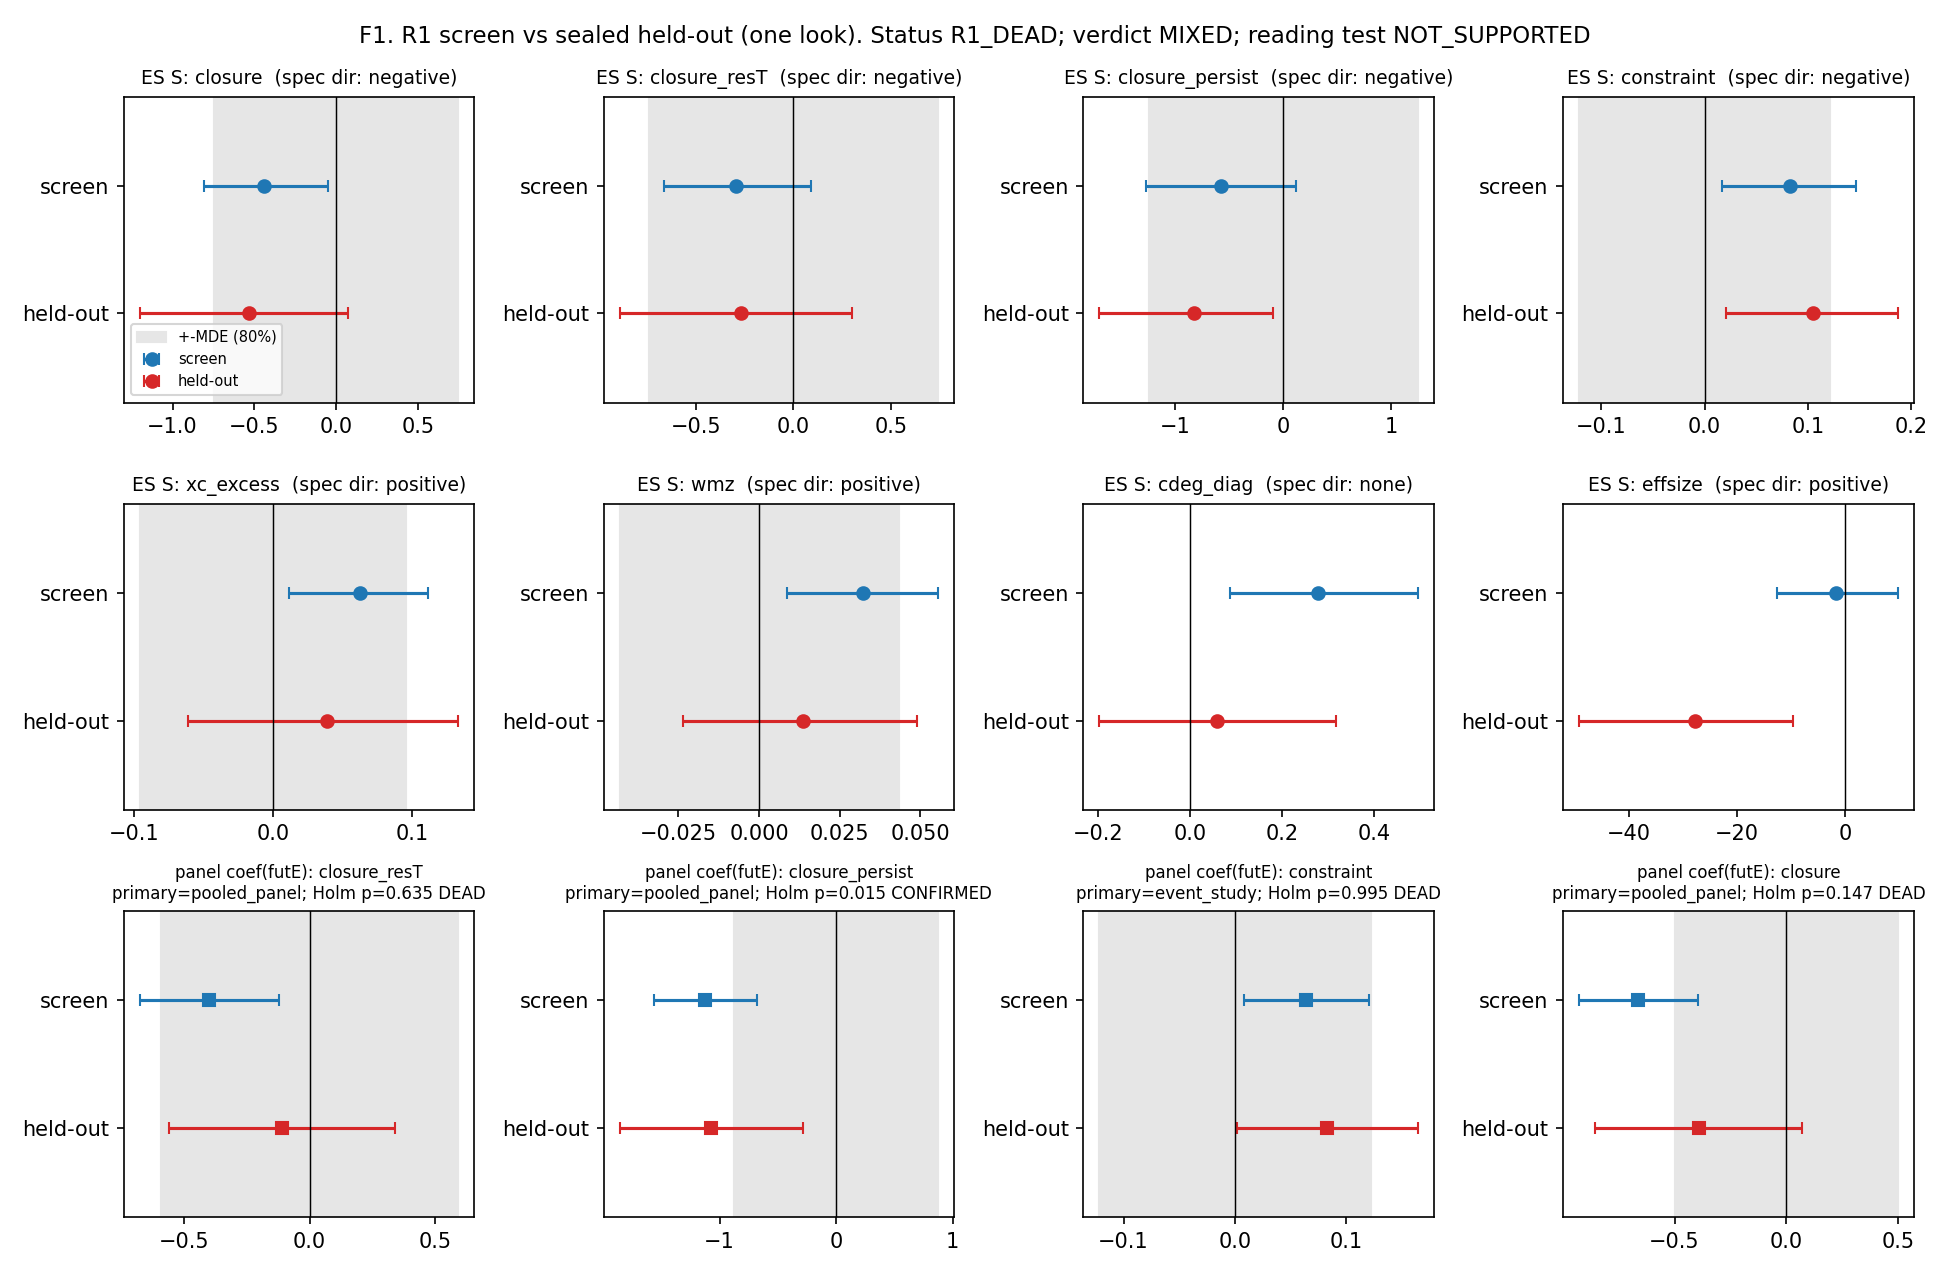

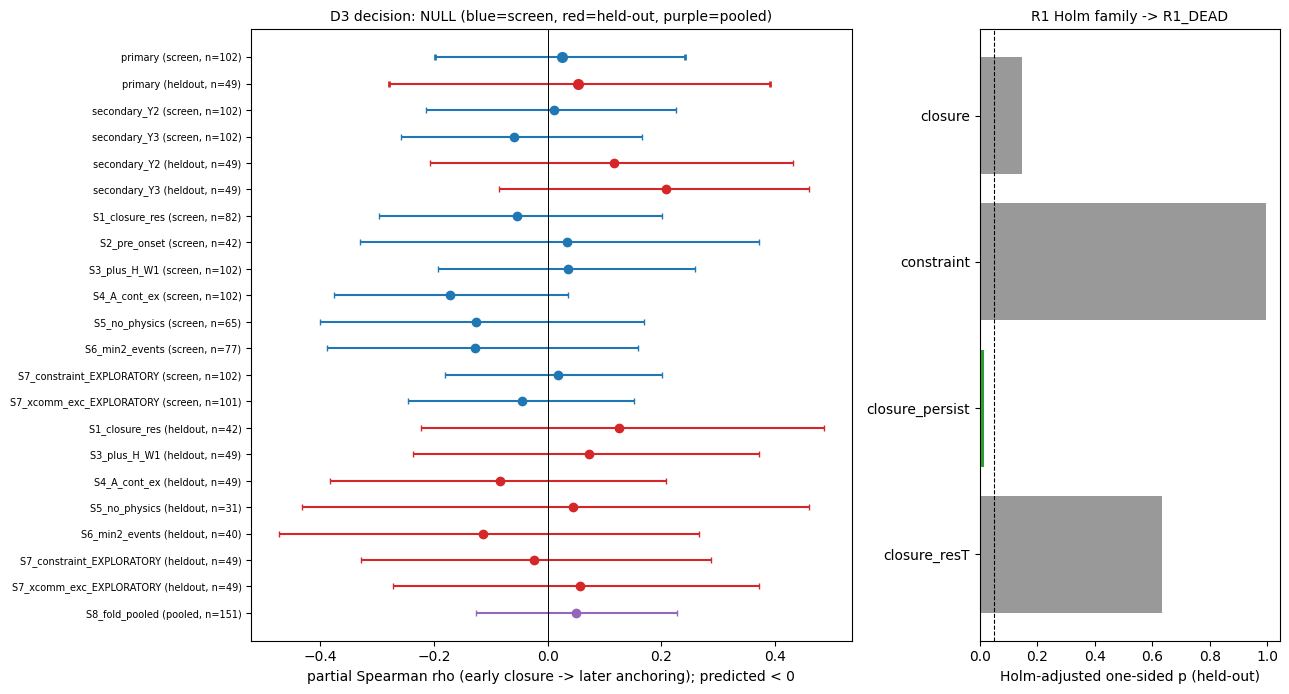

metrics_agg reproduction: 78/78 metrics identical to the original run


# Results note (held-out R1, D3)

**Held-out R1 (one look, spec 535c2dd3).** Under the kill mapping frozen before opening, R1 is **R1_DEAD**: the raw-closure pooled-panel coefficient keeps its negative sign (-0.391, one-sided p = 0.049) but fails Holm (p = 0.147); closure_resT is DEAD (Holm p = 0.635); and persistent-neighbour closure is CONFIRMED on the held-out fold (-1.073, Holm p = 0.015). The mechanical verdict is MIXED again, and the reading test is NOT_SUPPORTED. Constraint is positive once more, S = +0.105 [+0.021, +0.187], and xc_excess is S = +0.038 [-0.061, +0.133]. Caveat: the pre-declared fallback fired (fewer than 20 matched), so both estimators also use screen never-concepts as controls. Because raw closure does not survive Holm, the claimed tension between Cheng et al. (2023), where ideas become core through focused discourse and a fit with existing traditions (i.e. higher constraint), and Salatino et al. (2017), where cross-fertilisation of weakly connected areas precedes emergence (sparse, cross-community associates), is moot as a confirmed RQ1 finding. It survives only as a descriptive pattern: the redundant wider ego network (constraint > 0, replicated with CI excluding 0) is closer to Cheng et al., and the persistent top neighbours being less closed is closer to Salatino et al. The RQ1 sentence therefore becomes 'structural precursors are volume/churn correlates', qualified by the confirmed persistent-neighbour row. D3 is **NULL**: partial rho = +0.025 [-0.199, +0.242] on the screen (n = 102, p = 0.60) and +0.053 [-0.279, +0.391] on the held-out fold (n = 49, MDE 0.38). The 'one mechanism at two scales' sentence is dropped, and the paper reports RQ1 and RQ2-D2 as separate findings.


In [15]:
%matplotlib inline
out = json.loads((WS / "eval_out.json").read_text())
m = out["metrics_agg"]
print("Labels:", json.dumps(out["metadata"]["labels"], indent=1))
print(f"\n{len(m)} metrics, {sum(len(d['examples']) for d in out['datasets'])} examples "
      f"({', '.join(d['dataset'] + ':' + str(len(d['examples'])) for d in out['datasets'])})")
key = ["integrity_n_ok", "integrity_n_checks", "pytest_exp5_passed", "pytest_exp6_passed", "r1_n_onsets",
       "r1_n_matched_before_fallback", "r1_n_matched", "r1_retention_ratio", "r1_n_smd_flagged",
       "d3_partial_rho_screen", "d3_p_one_screen", "d3_n_screen", "d3_partial_rho_heldout", "d3_p_one_heldout",
       "d3_n_heldout", "d3_audit_max_abs_diff", "d3_perm_null_share_p_lt_005"]
display(pd.DataFrame([(k, m.get(k)) for k in key], columns=["metric", "value"]))

# Holm family on the held-out fold
holm = pd.read_csv(TAB / "r1_holm_decisions.csv")
display(holm[[c for c in ["row", "estimator", "coef", "S", "se", "p_one", "p_one_holm", "decision"] if c in holm.columns]])

# F1 forest plot saved by r1_forest()
display(Image(filename=str(FIG / "F1_r1_forest.png")))

# D3: partial rho (+ bootstrap CI) for every analysis with n >= 10; R1: held-out Holm p per row
d3ex = [e for e in out["datasets"][2]["examples"]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, max(3.5, 0.32 * len(d3ex))), gridspec_kw=dict(width_ratios=[2, 1]))
labs = [f"{e['metadata_analysis']} ({e['metadata_fold']}, n={int(e['eval_n'])})" for e in d3ex]
y = np.arange(len(d3ex))[::-1]
for yi, e in zip(y, d3ex):
    col = "tab:red" if e["metadata_fold"] == "heldout" else ("tab:blue" if e["metadata_fold"] == "screen" else "tab:purple")
    a1.errorbar(e["eval_partial_rho"], yi, xerr=[[e["eval_partial_rho"] - e["eval_ci_lo"]], [e["eval_ci_hi"] - e["eval_partial_rho"]]],
                fmt="o", color=col, capsize=2, mew=2 if e["metadata_analysis"] == "primary" else 1)
a1.axvline(0, color="k", lw=0.7)
a1.set_yticks(y, labs, fontsize=7)
a1.set_xlabel("partial Spearman rho (early closure -> later anchoring); predicted < 0")
a1.set_title(f"D3 decision: {out['metadata']['labels']['d3_decision']} (blue=screen, red=held-out, purple=pooled)", fontsize=10)
hr = [r for r in HOLM_ROWS]
hp = [m[f"r1_{r}_p_one_holm"] for r in hr]
a2.barh(hr, hp, color=["tab:green" if m[f"r1_{r}_confirmed"] else "0.6" for r in hr])
a2.axvline(0.05, color="k", ls="--", lw=0.8)
a2.set_xlabel("Holm-adjusted one-sided p (held-out)")
a2.set_title(f"R1 Holm family -> {out['metadata']['labels']['r1_status']}", fontsize=10)
fig.tight_layout()
plt.show()

# Reproduction check against the original eval_out.json metrics
ref = data.get("reference_metrics_agg", {})
diff = [k for k in ref if not (k in m and (m[k] == ref[k] or (isinstance(ref[k], float) and abs(m[k] - ref[k]) < 1e-9)))]
print(f"metrics_agg reproduction: {len(ref) - len(diff)}/{len(ref)} metrics identical to the original run" + (f"; differing: {diff}" if diff else ""))

display(Markdown((WS / "results_note.md").read_text()))
